# Trabajo Práctico de Aprendizaje de Máquina

Integrantes:
- Luciana Simón
- Matías Souto
- Yoharlyn Alvarez

## Contexto y planteamiento del problema

En la industria aérea, la satisfacción del pasajero es un indicador clave: incide directamente en la retención de clientes, en la reputación de la aerolínea y en decisiones operativas sobre qué servicios priorizar (embarque, comodidad de asientos, puntualidad, entretenimiento a bordo, etc.). Contar con un modelo que anticipe si un pasajero calificará su experiencia como satisfactoria le permite a la aerolínea identificar de forma proactiva a los clientes en riesgo de insatisfacción y accionar sobre las variables de servicio que más pesan en esa percepción.

**Tipo de problema:** se trata de un problema de **clasificación binaria**. A partir de las características del pasajero, del vuelo y de sus calificaciones de servicio, buscamos predecir si calificará el vuelo como `satisfied` o `neutral or dissatisfied`. Por prolijidad, a esta última la renombramos `not_satisfied` a lo largo del análisis.

**Costo asimétrico de los errores:** para el negocio, no todos los errores de clasificación pesan igual. Sospechamos que es más costoso un **falso positivo** (predecir que un pasajero está satisfecho cuando en realidad no lo está) que un falso negativo. Si el modelo predice satisfacción de forma incorrecta, ese pasajero insatisfecho no dispara ninguna acción correctiva de parte de la aerolínea; en cambio, si el modelo es conservador y predice insatisfacción de más, en el peor de los casos se revisa un caso que ya estaba bien. Esta asimetría es la que después nos va a llevar a priorizar precisión por sobre recall al elegir la métrica de evaluación (`fbeta_score` con `beta=0.5`).


## Dataset: Airline Passenger Satisfaction
Vamos a trabajar el problema sobre el siguiente dataset: [Airline Passenger Satisfaction](https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction)

Este dataset contiene una encuesta sobre la satisfacción de los pasajeros de una compañía aérea.


| Columna      | Descripción                                                                      |
| ------------- | ---------------------------------------------------------------------------------- |
| `Gender`    | Sexo (`Female`, `Male`)                                                  |
| `Customer Type`         | Tipo de cliente (`Loyal customer`, `disloyal customer`)                                               |
| `Age`         | Edad                                                        |
| `Type of Travel`       | Motivo del viaje (`Personal Travel`, `Business Travel`)                                               |
| `Class`       | Clase de viaje en el avión (`Business`, `Eco`, `Eco Plus`)                                                   |
| `Flight distance`        | Distancia de vuelo                                                        |
| `Inflight wifi service`    | Nivel de satisfacción con el servicio de wifi (`0`:`No Aplica`;`1-5`)          |
| `Departure/Arrival time convenient`       | Nivel de satisfacción con respecto a la conveniencia de los horarios de salida y llegada del vuelo (`0`:`No Aplica`;`1-5`) |
| `Ease of Online booking`         | Nivel de satisfacción con la reserva en línea (`0`:`No Aplica`;`1-5`) |
| `Gate location`  | Nivel de satisfacción con la ubicación de la puerta (`0`:`No Aplica`;`1-5`)                                                    |
| `Food and drink`        | Nivel de satisfacción con la comida y la bebida (`0`:`No Aplica`;`1-5`)                             |
| `Online boarding` | Nivel de satisfacción con los trámites de embarque en línea (`0`:`No Aplica`;`1-5`)                                              |
| `Seat comfort` | Nivel de satisfacción con la comodidad de los asientos (`0`:`No Aplica`;`1-5`)                                               |
| `Inflight entertainment` | Nivel de satisfacción con el entretenimiento a bordo (`0`:`No Aplica`;`1-5`)                                               |
| `On-board service` | Nivel de satisfacción con el servicio para abordar (`0`:`No Aplica`;`1-5`)                                               |
| `Leg room service` | Nivel de satisfacción con el espacio para las piernas (`0`:`No Aplica`;`1-5`)                                               |
| `Baggage handling` | Nivel de satisfacción con la gestión del equipaje (`0`:`No Aplica`;`1-5`)                                               |
| `Check-in service` | Nivel de satisfacción con el servicio de facturación (`0`:`No Aplica`;`1-5`)                                               |
| `Inflight service` | Nivel de satisfacción con el servicio a bordo (`0`:`No Aplica`;`1-5`)                                               |
| `Cleanliness` | Nivel de satisfacción con la limpieza (`0`:`No Aplica`;`1-5`)                                               |
| `Departure Delay in Minutes` | Minutos de retraso en la salida (`0`:`No Aplica`;`1-5`)                                               |
| `Arrival Delay in Minutes`       | Minutos de retraso en la llegada (`0`:`No Aplica`;`1-5`)                                                    |
| `Satisfaction`       | Nivel de satisfacción con la compañía aérea (`satisfied`, `neutral or dissatisfied`)

## Importamos las librerías

In [1]:
import pandas as pd
import zipfile
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from io import BytesIO
from pandas.api.types import CategoricalDtype
from scipy import stats as st
from scipy.stats import chi2_contingency, kendalltau, f_oneway, pointbiserialr

from preprocessing.eda_funcs import get_frecuency, get_null_groups
from graphs.eda_graphs import plot_service_distribution, plot_kendall,plot_crosstab
from models.baseline import BaselineClassifier
from models.metrics import eval_metrics, MetricsCollector

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif, chi2, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict

## Cargamos el Dataset

In [2]:
# Leemos los datos de kaggle
url = "https://www.kaggle.com/api/v1/datasets/download/teejmahal20/airline-passenger-satisfaction"

response = requests.get(url)
zip_file = zipfile.ZipFile(BytesIO(response.content))
zip_file.namelist()

['test.csv', 'train.csv']

In [3]:
# Droppeamos una columna Unnamed 
df_train = pd.read_csv(zip_file.open("train.csv"))
df_train.drop("Unnamed: 0", axis=1, inplace=True)

df_test = pd.read_csv(zip_file.open("test.csv"))
df_test.drop("Unnamed: 0", axis=1, inplace=True)

In [4]:
# Guardamos los datasets raw
df_train.to_csv("./datasets/df_train_original.csv", index=False )
df_test.to_csv("./datasets/df_test_original.csv", index=False )

## Analisis Exploratorio de los datos

In [5]:
df_train.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [6]:
df_train.shape

(103904, 24)

In [7]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 103904 non-null  int64  
 1   Gender                             103904 non-null  str    
 2   Customer Type                      103904 non-null  str    
 3   Age                                103904 non-null  int64  
 4   Type of Travel                     103904 non-null  str    
 5   Class                              103904 non-null  str    
 6   Flight Distance                    103904 non-null  int64  
 7   Inflight wifi service              103904 non-null  int64  
 8   Departure/Arrival time convenient  103904 non-null  int64  
 9   Ease of Online booking             103904 non-null  int64  
 10  Gate location                      103904 non-null  int64  
 11  Food and drink                     103904 non-null

In [8]:
df_train.iloc[0]

id                                                     70172
Gender                                                  Male
Customer Type                                 Loyal Customer
Age                                                       13
Type of Travel                               Personal Travel
Class                                               Eco Plus
Flight Distance                                          460
Inflight wifi service                                      3
Departure/Arrival time convenient                          4
Ease of Online booking                                     3
Gate location                                              1
Food and drink                                             5
Online boarding                                            3
Seat comfort                                               5
Inflight entertainment                                     5
On-board service                                           4
Leg room service        

In [9]:
df_train.isna().sum()

id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction                           0
dtype: int64

In [10]:
df_train.duplicated().sum()

np.int64(0)

In [11]:
df_train.describe()

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,64924.210502,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678
std,37463.812252,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682
min,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,97368.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [12]:
df_train.describe(include=["object", "str"])

,Gender,Customer Type,Type of Travel,Class,satisfaction
count,103904,103904,103904,103904,103904
unique,2,2,2,3,2
top,Female,Loyal Customer,Business travel,Business,neutral or dissatisfied
freq,52727,84923,71655,49665,58879


In [13]:
df_train.nunique().sort_values(ascending=False)

id                                   103904
Flight Distance                        3802
Arrival Delay in Minutes                455
Departure Delay in Minutes              446
Age                                      75
Departure/Arrival time convenient         6
Ease of Online booking                    6
Inflight wifi service                     6
On-board service                          6
Inflight entertainment                    6
Leg room service                          6
Checkin service                           6
Online boarding                           6
Seat comfort                              6
Gate location                             6
Food and drink                            6
Cleanliness                               6
Inflight service                          6
Baggage handling                          5
Class                                     3
Type of Travel                            2
Customer Type                             2
Gender                          

### Búsqueda de relación entre variables

In [14]:
numeric_columns = [
    "Age",
    "Flight Distance",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]

nominal_categorical__columns = [
    "Gender",
    "Customer Type",
    "Type of Travel",
    "Class",
    "satisfaction"
]

service_columns = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Inflight service",
    "Cleanliness"
]

In [15]:
zero_summary = pd.DataFrame({
    "cantidad_ceros": (df_train[service_columns] == 0).sum(),
    "porcentaje_ceros": (
        (df_train[service_columns] == 0).mean() * 100
    ).round(2)
}).sort_values("porcentaje_ceros", ascending=False)

zero_summary

,cantidad_ceros,porcentaje_ceros
Departure/Arrival time convenient,5300,5.10
Ease of Online booking,4487,4.32
Inflight wifi service,3103,2.99
Online boarding,2428,2.34
Leg room service,472,0.45
Food and drink,107,0.10
Cleanliness,12,0.01
Inflight entertainment,14,0.01
Gate location,1,0.00
Seat comfort,1,0.00


Algunas de las variables que proveen el nivel de satisfacción de los diferentes servicios tienen valores 0. Esto no quiere decir que sea un dato faltante. En la documentación indican que el 0 es equivalente a "No Aplica". Por esta razón es que en parte del análisis que hacemos más adelante sobre estas variables, serán descartadas las filas que no apliquen. 

In [16]:
df_plot = df_train.copy()

for col in service_columns:
    df_plot[col] = df_plot[col].replace(0, "No aplica")

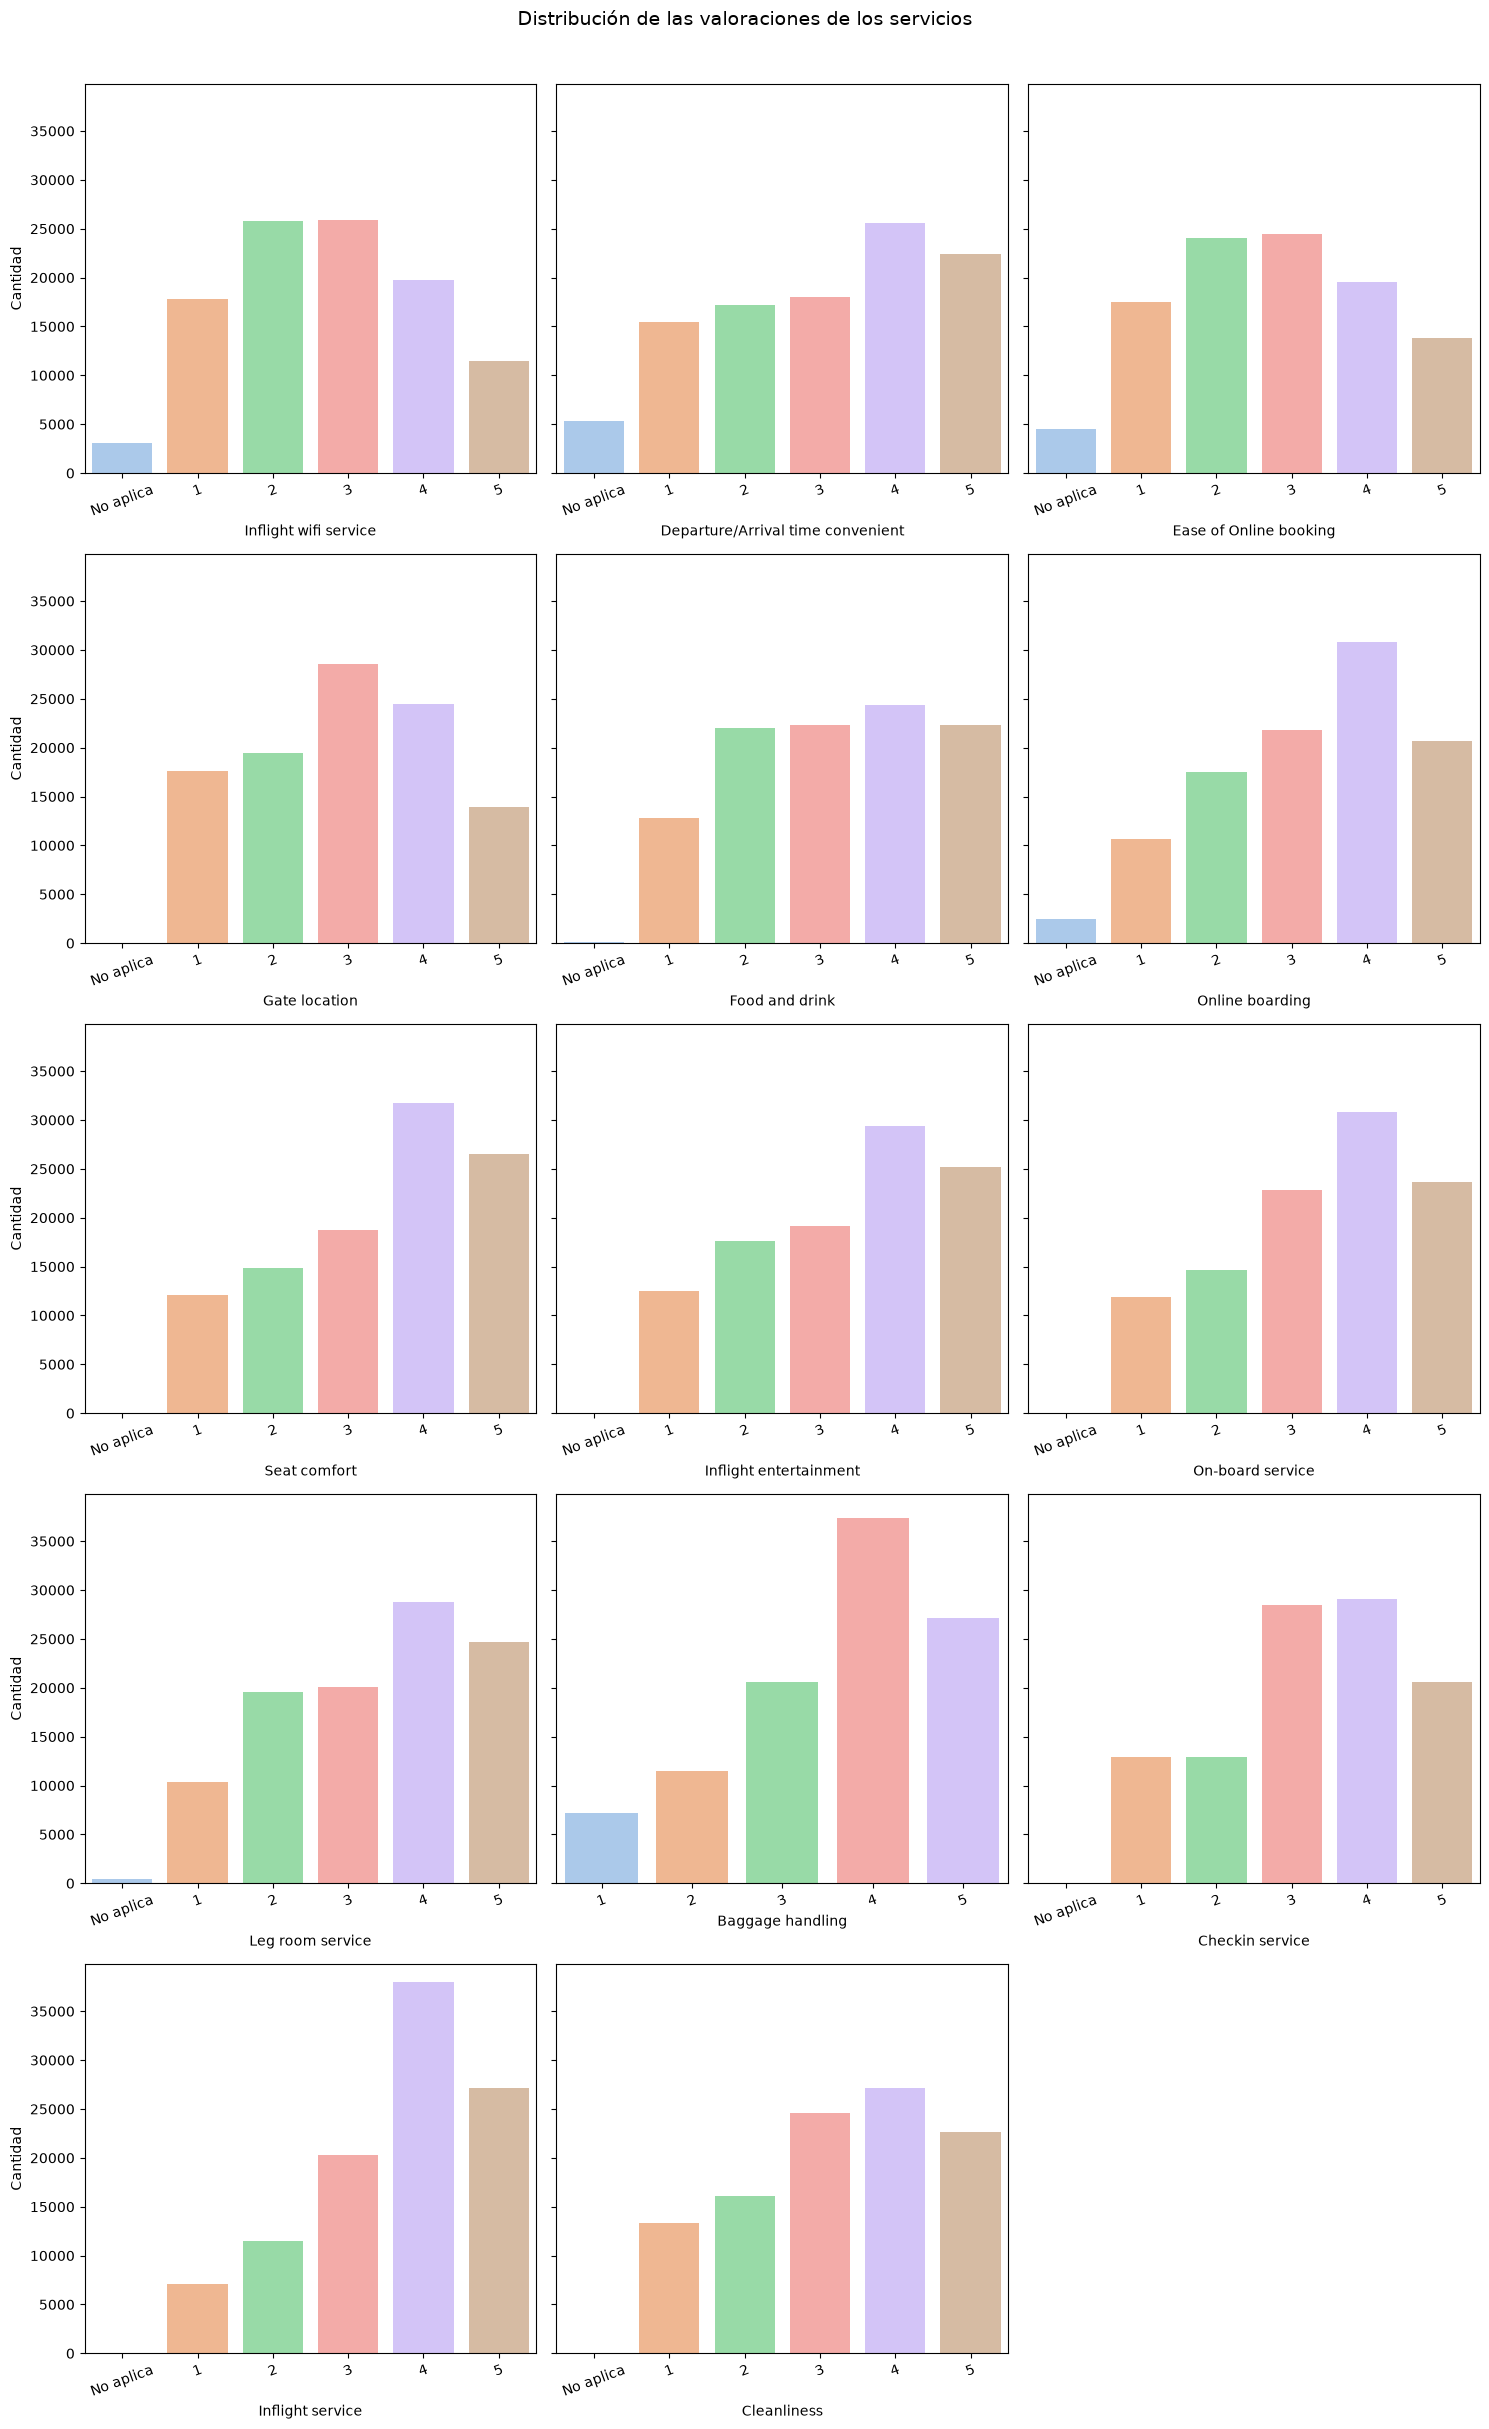

In [17]:
plot_service_distribution(df_plot, service_columns)


In [18]:
services_for_analysis = df_train[service_columns].replace(0, np.nan)
services_for_analysis.describe()

,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness
count,100801.000000,98604.000000,99417.000000,103903.000000,103797.000000,101476.000000,103903.000000,103890.00000,103901.000000,103432.000000,103904.000000,103903.000000,103901.000000,103892.000000
mean,2.813712,3.224788,2.881328,2.976911,3.205430,3.328147,3.439429,3.35861,3.382460,3.366347,3.631833,3.304322,3.640533,3.286730
std,1.257367,1.385790,1.298773,1.277594,1.326235,1.267246,1.319051,1.33251,1.288245,1.298936,1.180903,1.265360,1.175517,1.311873
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000
50%,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.00000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000
75%,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.00000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


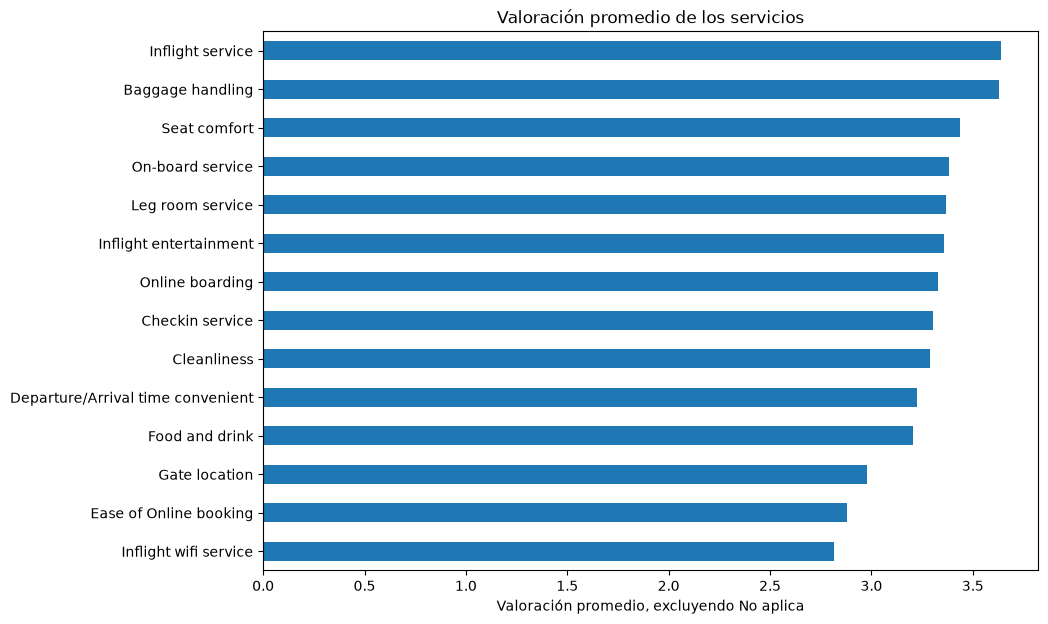

In [19]:
mean_services = (
    services_for_analysis
    .mean()
    .sort_values()
)

mean_services.plot(kind="barh", figsize=(10, 7))
plt.xlabel("Valoración promedio, excluyendo No aplica")
plt.title("Valoración promedio de los servicios")
plt.show()

In [20]:
df_analysis = df_train.copy()

df_analysis[numeric_columns] = (
    df_analysis[numeric_columns]
    .astype("float64")
)

df_analysis[nominal_categorical__columns] = (
    df_analysis[nominal_categorical__columns]
    .astype("category")
)

service_dtype = CategoricalDtype(
    categories=[1, 2, 3, 4, 5],
    ordered=True
)

for col in service_columns:
    df_analysis[col] = (
        df_analysis[col]
        .replace(0, np.nan)
        .astype(service_dtype)
    )

df_analysis.info()

<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype   
---  ------                             --------------   -----   
 0   id                                 103904 non-null  int64   
 1   Gender                             103904 non-null  category
 2   Customer Type                      103904 non-null  category
 3   Age                                103904 non-null  float64 
 4   Type of Travel                     103904 non-null  category
 5   Class                              103904 non-null  category
 6   Flight Distance                    103904 non-null  float64 
 7   Inflight wifi service              100801 non-null  category
 8   Departure/Arrival time convenient  98604 non-null   category
 9   Ease of Online booking             99417 non-null   category
 10  Gate location                      103903 non-null  category
 11  Food and drink                     10

In [21]:
df_analysis["Inflight wifi service"].dtype

CategoricalDtype(categories=[1, 2, 3, 4, 5], ordered=True, categories_dtype=int64)

In [22]:
get_frecuency(df_analysis, "Customer Type")

Frecuencias de cada categoría en la variable 'Customer Type':
                   Frecuencia absoluta  Frecuencia relativa (%)
Customer Type                                                  
Loyal Customer                   84923                    81.73
disloyal Customer                18981                    18.27



In [23]:
get_frecuency(df_analysis, "Class")

Frecuencias de cada categoría en la variable 'Class':
          Frecuencia absoluta  Frecuencia relativa (%)
Class                                                 
Business                49665                    47.80
Eco                     46745                    44.99
Eco Plus                 7494                     7.21



In [24]:
get_frecuency(df_analysis, "satisfaction")

Frecuencias de cada categoría en la variable 'satisfaction':
                         Frecuencia absoluta  Frecuencia relativa (%)
satisfaction                                                         
neutral or dissatisfied                58879                    56.67
satisfied                              45025                    43.33



In [25]:
pearson_corr = df_analysis[numeric_columns].corr(method="pearson")
pearson_corr

,Age,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes
Age,1.000000,0.099461,-0.010152,-0.012147
Flight Distance,0.099461,1.000000,0.002158,-0.002426
Departure Delay in Minutes,-0.010152,0.002158,1.000000,0.965481
Arrival Delay in Minutes,-0.012147,-0.002426,0.965481,1.000000


In [26]:
spearman_continuous = df_analysis[numeric_columns].corr(method="spearman")
spearman_continuous

,Age,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes
Age,1.000000,0.072321,-0.010894,-0.012439
Flight Distance,0.072321,1.000000,0.026570,-0.001468
Departure Delay in Minutes,-0.010894,0.026570,1.000000,0.740843
Arrival Delay in Minutes,-0.012439,-0.001468,0.740843,1.000000


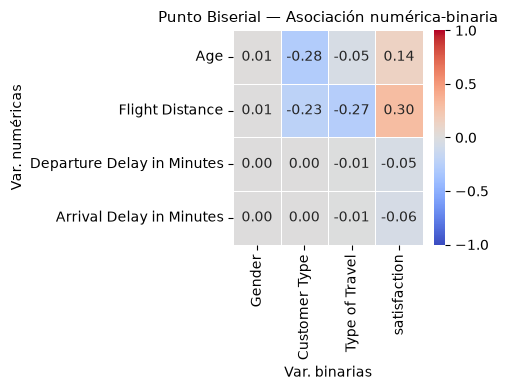

In [27]:
binary_columns = [
    "Gender",
    "Customer Type",
    "Type of Travel",
    "satisfaction"
]

pb_values = np.empty(
    (len(numeric_columns), len(binary_columns)),
    dtype=float
)

for i, num_col in enumerate(numeric_columns):
    for j, bin_col in enumerate(binary_columns):
        mask = (
            df_analysis[num_col].notna()
            & df_analysis[bin_col].notna()
        )

        num = (
            df_analysis.loc[mask, num_col]
            .to_numpy(dtype=float)
        )

        bn = (
            df_analysis.loc[mask, bin_col]
            .cat.codes
            .to_numpy(dtype=float)
        )

        pb_values[i, j] = np.corrcoef(bn, num)[0, 1]


pb_mat = pd.DataFrame(
    pb_values,
    index=numeric_columns,
    columns=binary_columns
)
        

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(pb_mat.astype(float), annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.5,
            center=0, ax=ax)

ax.set_title("Punto Biserial — Asociación numérica-binaria", fontsize=11)
ax.set_xlabel("Var. binarias")
ax.set_ylabel("Var. numéricas")
plt.tight_layout()
plt.show()

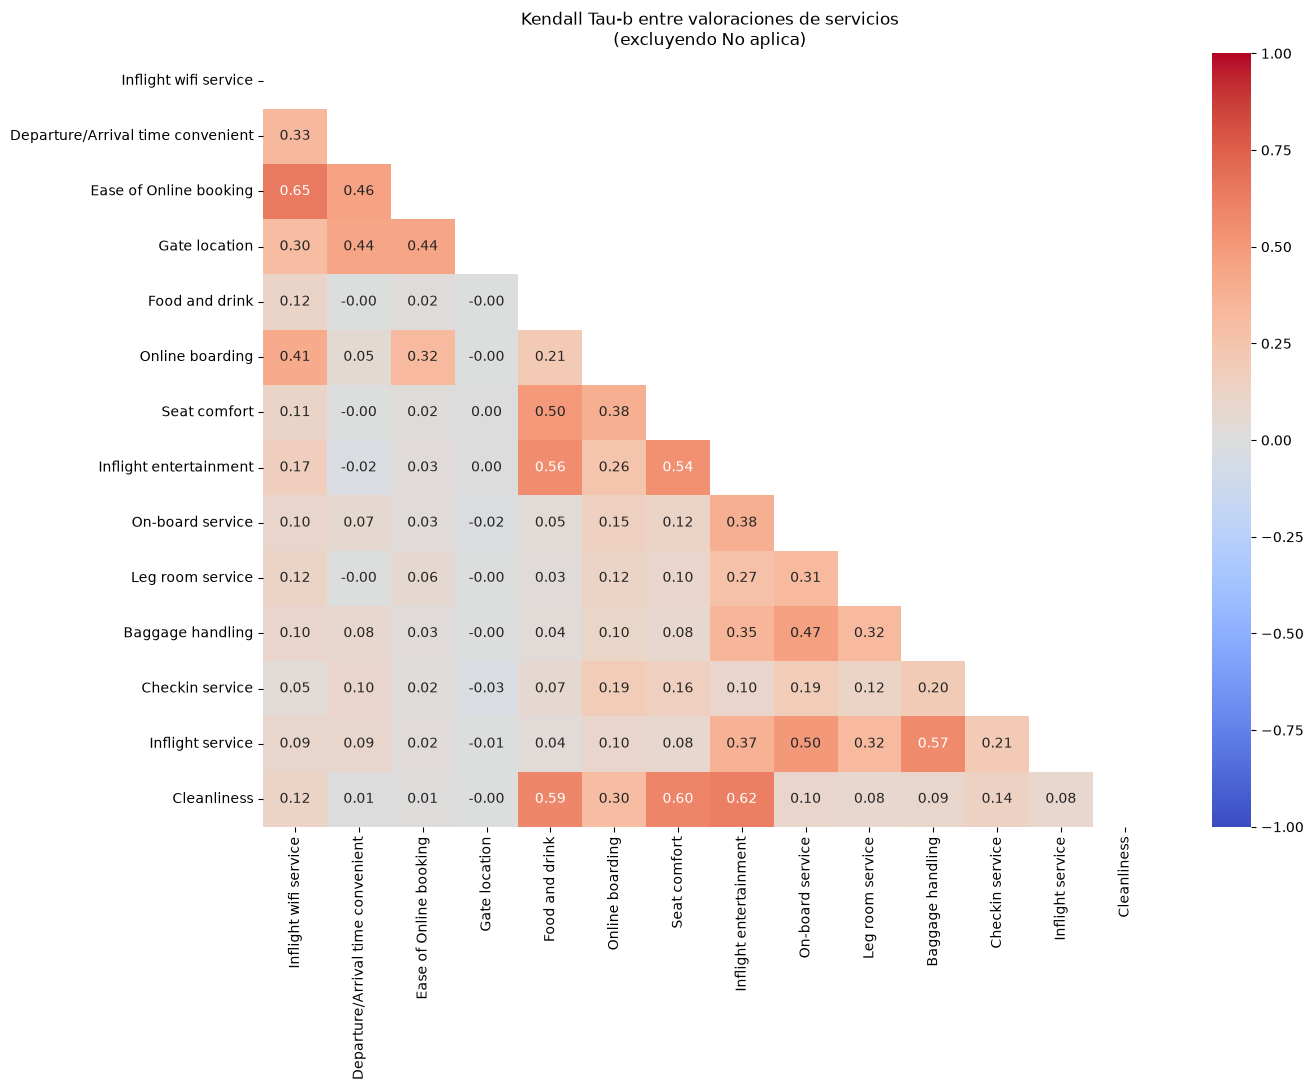

In [28]:
services_for_corr = (
    df_train[service_columns]
    .replace(0, np.nan)
)
plot_kendall(services_for_corr)

In [29]:
binary_column = "satisfaction"

results_tau = {}

for ord_col in service_columns:
    mask = (
        df_analysis[binary_column].notna()
        & df_analysis[ord_col].notna()
    )

    binary_codes = (
        df_analysis.loc[mask, binary_column]
        .cat.codes
    )

    ordinal_codes = (
        df_analysis.loc[mask, ord_col]
        .cat.codes
    )

    tau, p_value = kendalltau(
        binary_codes,
        ordinal_codes,
        variant="b"
    )

    results_tau[ord_col] = {
        "tau_b": tau,
        "p_value": p_value,
        "n": mask.sum()
    }

kendall_results = pd.DataFrame(results_tau).T

In [30]:
kendall_results = kendall_results.loc[
    kendall_results["tau_b"]
    .abs()
    .sort_values()
    .index
]

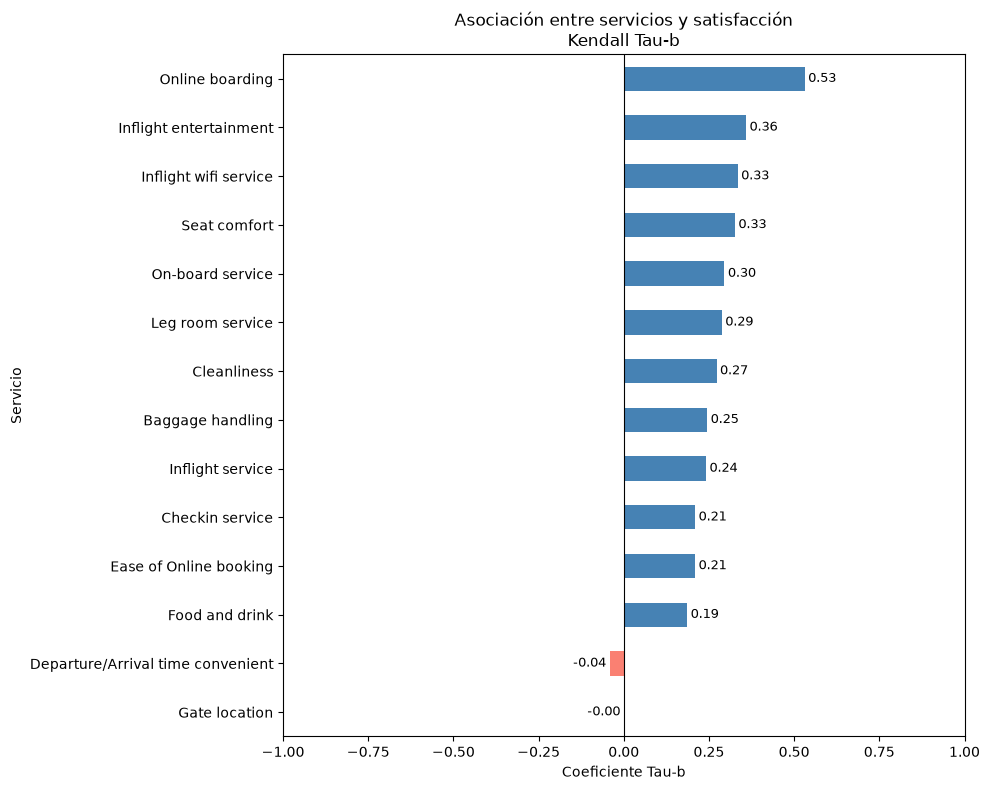

In [31]:
plt.figure(figsize=(10, 8))

tau_values = kendall_results["tau_b"].to_numpy(dtype=float)

colors = [
    "salmon" if value < 0 else "steelblue"
    for value in tau_values
]

ax = kendall_results["tau_b"].plot(
    kind="barh",
    color=colors
)

ax.axvline(
    0,
    color="black",
    linewidth=0.8
)

ax.set_xlim(-1, 1)

ax.set_title(
    "Asociación entre servicios y satisfacción\n"
    "Kendall Tau-b"
)

ax.set_xlabel("Coeficiente Tau-b")
ax.set_ylabel("Servicio")

for y_position, value in enumerate(tau_values):
    ax.text(
        x=value + 0.01 if value >= 0 else value - 0.01,
        y=y_position,
        s=f"{value:.2f}",
        va="center",
        ha="left" if value >= 0 else "right",
        fontsize=9
    )

plt.tight_layout()
plt.show()

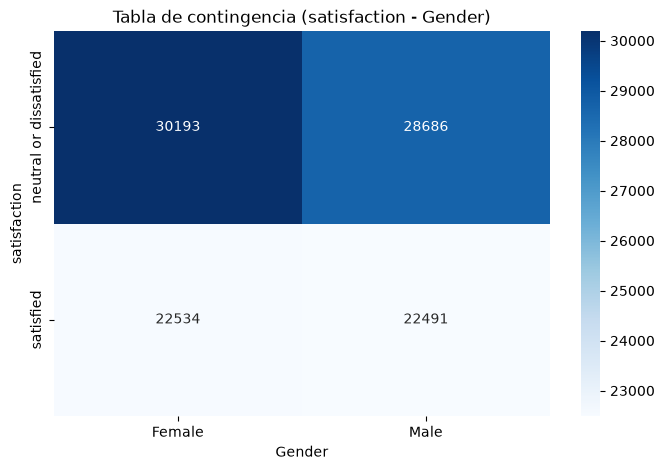

In [32]:
plot_crosstab(df_analysis["satisfaction"], df_analysis["Gender"])

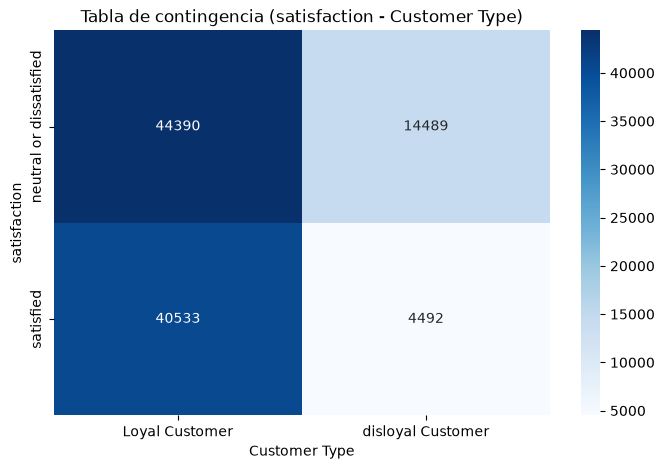

In [33]:
plot_crosstab(df_analysis["satisfaction"], df_analysis["Customer Type"])

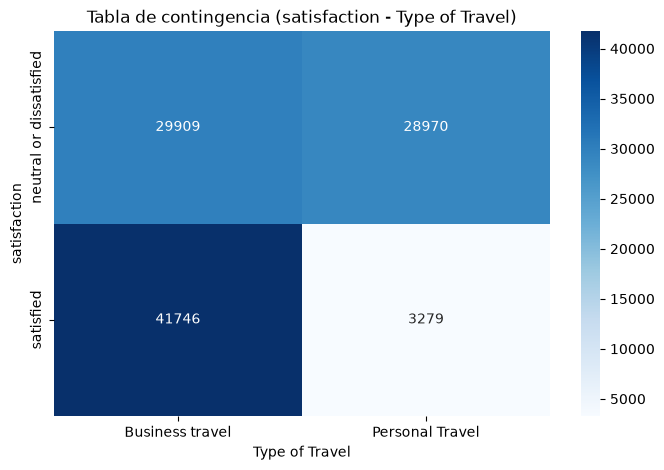

In [34]:
plot_crosstab(df_analysis["satisfaction"], df_analysis["Type of Travel"])

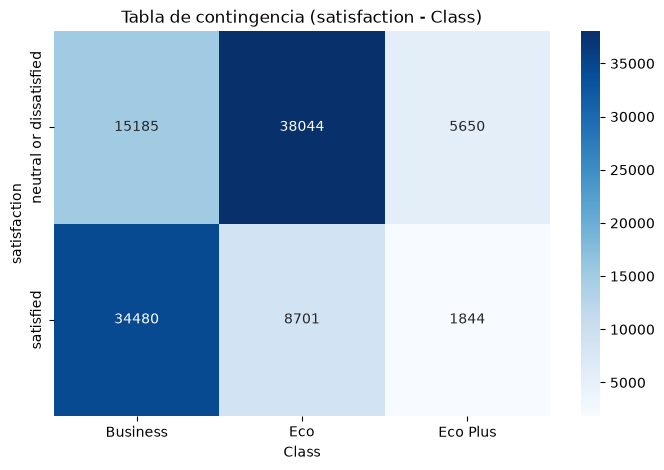

In [35]:
plot_crosstab(df_analysis["satisfaction"], df_analysis["Class"])

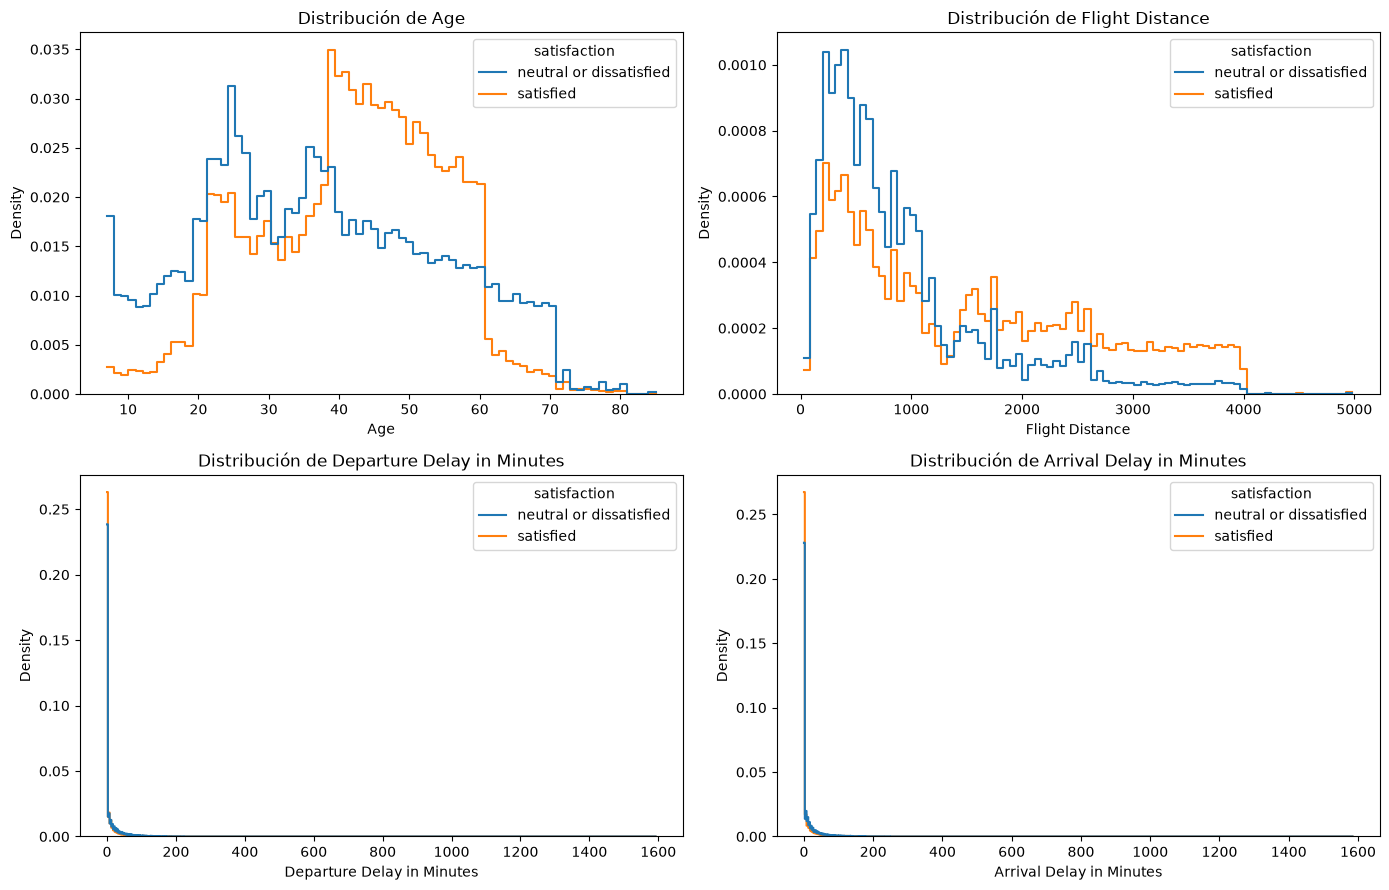

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, col in zip(axes, numeric_columns):
    sns.histplot(
        data=df_analysis,
        x=col,
        hue="satisfaction",
        stat="density",
        common_norm=False,
        element="step",
        fill=False,
        ax=ax
    )
    ax.set_title(f"Distribución de {col}")

plt.tight_layout()
plt.show()

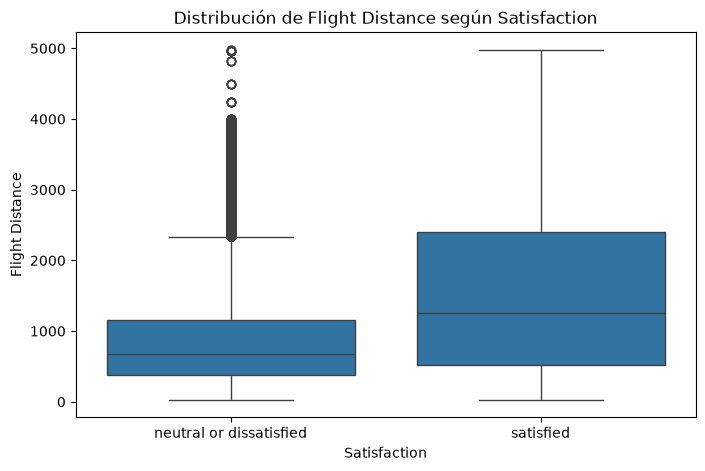

In [37]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_analysis,
    x="satisfaction",
    y="Flight Distance"

)

plt.title("Distribución de Flight Distance según Satisfaction")
plt.xlabel("Satisfaction")
plt.ylabel("Flight Distance")
plt.show()

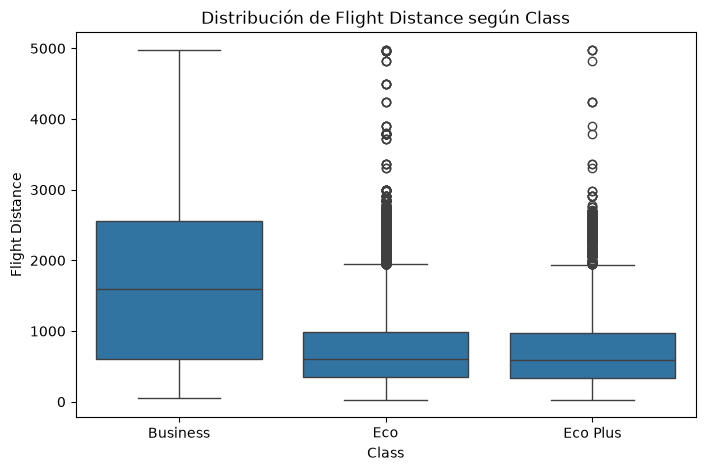

In [38]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_analysis,
    x="Class",
    y="Flight Distance"

)

plt.title("Distribución de Flight Distance según Class")
plt.xlabel("Class")
plt.ylabel("Flight Distance")
plt.show()

In [39]:
Q1 = df_analysis["Flight Distance"].quantile(0.25)
Q3 = df_analysis["Flight Distance"].quantile(0.75)

IQR = Q3 - Q1

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Límite inferior: {lower_bound}")
print(f"Límite superior: {upper_bound}")

outliers = df_analysis[
    (df_analysis["Flight Distance"] < lower_bound) |
    (df_analysis["Flight Distance"] > upper_bound)
]

print(f"Cantidad de outliers: {len(outliers)}")

Q1: 414.0
Q3: 1743.0
IQR: 1329.0
Límite inferior: -1579.5
Límite superior: 3736.5
Cantidad de outliers: 2291


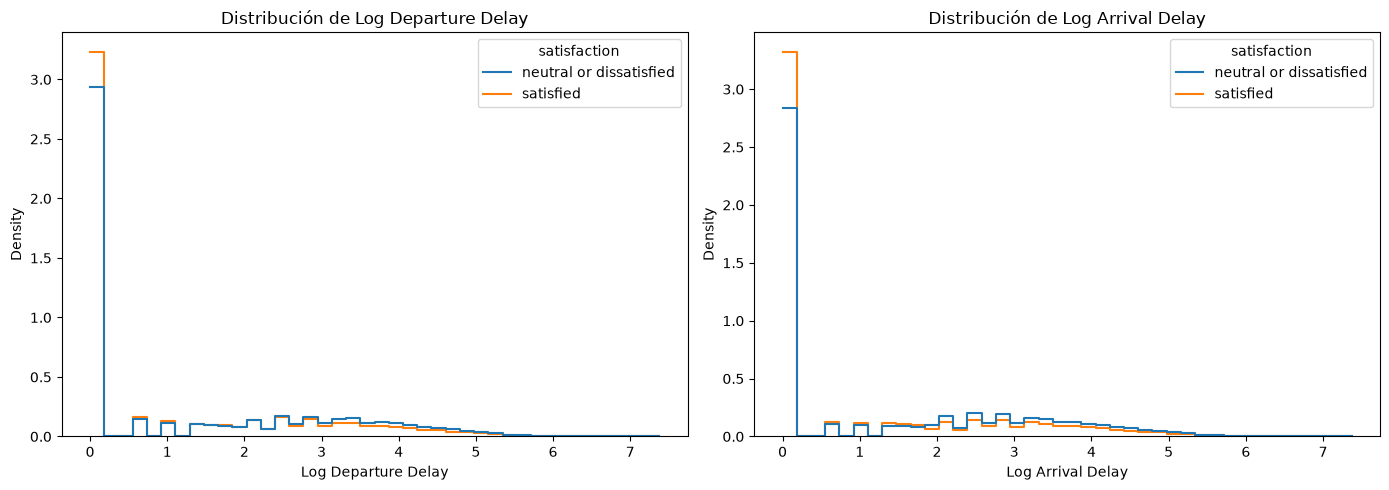

In [40]:
df_plot = df_analysis.copy()

df_plot["Log Departure Delay"] = np.log1p(
    df_plot["Departure Delay in Minutes"]
)

df_plot["Log Arrival Delay"] = np.log1p(
    df_plot["Arrival Delay in Minutes"]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(
    axes,
    ["Log Departure Delay", "Log Arrival Delay"]
):
    sns.histplot(
        data=df_plot,
        x=col,
        hue="satisfaction",
        stat="density",
        common_norm=False,
        element="step",
        fill=False,
        bins=40,
        ax=ax
    )

    ax.set_title(f"Distribución de {col}")

plt.tight_layout()
plt.show()

**Resumen de hallazgos:** La variable de satisfacción presenta un desbalance moderado: el 56,67 % de los pasajeros lo calificó neutral o insatisfecho y el 43,33 % satisfecho. La satisfacción se relaciona especialmente con el tipo de viaje, la clase y la fidelidad del cliente: es mayor entre clientes leales, con motivo de viaje de negocios y que viajan en clase Business. Por otra parte, vemos que el género no es relavante en esta calificación.

Entre los servicios, Online boarding presenta la asociación ordinal más fuerte con la satisfacción (Kendall Tau-b = 0,53), seguido por Inflight entertainment (0,36), Inflight wifi service y Seat comfort (0,33). En cambio, Gate location y Departure/Arrival time convenient muestran asociaciones prácticamente nulas. Respecto de las variables numéricas continuas, las demoras de salida y llegada están fuertemente correlacionadas (Pearson = 0,97), mientras que las restantes relaciones son débiles. También se observa que los pasajeros satisfechos tienden a realizar vuelos más largos y a presentar menores demoras.

### Datos faltantes

In [41]:
missing_summary = pd.DataFrame({
    "cantidad_faltantes": df_train.isna().sum(),
    "porcentaje_faltantes": (
        df_train.isna().mean() * 100
    ).round(4)
})

missing_summary

,cantidad_faltantes,porcentaje_faltantes
id,0,0.0000
Gender,0,0.0000
Customer Type,0,0.0000
Age,0,0.0000
Type of Travel,0,0.0000
Class,0,0.0000
Flight Distance,0,0.0000
Inflight wifi service,0,0.0000
Departure/Arrival time convenient,0,0.0000
Ease of Online booking,0,0.0000


La única columna que posee valores nulos es **Arrival Delay in Minutes** con un porcentaje bajo: **0.2984%**.

A continuación tratamos de identificar un patrón para la ausencia de este valor. De esa forma podemos establecer el mecanismo más adecuado para tratar esos datos faltantes.

In [42]:
group_columns = [
    "Gender",
    "Customer Type",
    "Type of Travel",
    "Class",
    "satisfaction"
]

for col in group_columns:
    display(
        get_null_groups(
            df_train,
            col,
            "Arrival Delay in Minutes"
        )
    )

,Gender,cantidad_total,cantidad_nulos,porcentaje_nulos
1,Male,51177,159,0.310686
0,Female,52727,151,0.286381


,Customer Type,cantidad_total,cantidad_nulos,porcentaje_nulos
0,Loyal Customer,84923,261,0.307337
1,disloyal Customer,18981,49,0.258153


,Type of Travel,cantidad_total,cantidad_nulos,porcentaje_nulos
1,Personal Travel,32249,120,0.372105
0,Business travel,71655,190,0.265159


,Class,cantidad_total,cantidad_nulos,porcentaje_nulos
2,Eco Plus,7494,26,0.346944
1,Eco,46745,152,0.325168
0,Business,49665,132,0.265781


,satisfaction,cantidad_total,cantidad_nulos,porcentaje_nulos
0,neutral or dissatisfied,58879,182,0.309109
1,satisfied,45025,128,0.284287


In [43]:
df_missing = df_train.copy()

df_missing["arrival_delay_missing"] = (
    df_missing["Arrival Delay in Minutes"].isna()
)

numeric_missing_comparison = (
    df_missing
    .groupby("arrival_delay_missing")[
        [
            "Age",
            "Flight Distance",
            "Departure Delay in Minutes"
        ]
    ]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

numeric_missing_comparison

Age                      Flight Distance           \
                        count   mean median    std           count     mean   
arrival_delay_missing                                                         
False                  103594  39.38   40.0  15.11          103594  1189.33   
True                      310  39.13   39.0  15.74             310  1230.61   

                                     Departure Delay in Minutes                \
                      median     std                      count   mean median   
arrival_delay_missing                                                           
False                  842.0  997.30                     103594  14.75    0.0   
True                   945.0  946.33                        310  37.43    8.0   

                              
                         std  
arrival_delay_missing         
False                  38.12  
True                   62.24

In [44]:
df_missing["departure_delay_group"] = pd.cut(
    df_missing["Departure Delay in Minutes"],
    bins=[-1, 0, 15, 60, np.inf],
    labels=[
        "Sin demora",
        "1–15 minutos",
        "16–60 minutos",
        "Más de 60 minutos"
    ]
)

missing_by_departure_delay = (
    df_missing
    .groupby("departure_delay_group", observed=True)
    .agg(
        cantidad_total=(
            "arrival_delay_missing",
            "size"
        ),
        cantidad_nulos=(
            "arrival_delay_missing",
            "sum"
        ),
        porcentaje_nulos=(
            "arrival_delay_missing",
            "mean"
        )
    )
)

missing_by_departure_delay["porcentaje_nulos"] *= 100

missing_by_departure_delay.round(3)

,cantidad_total,cantidad_nulos,porcentaje_nulos
departure_delay_group,,,
Sin demora,58668,116,0.198
1–15 minutos,22184,58,0.261
16–60 minutos,15813,68,0.430
Más de 60 minutos,7239,68,0.939


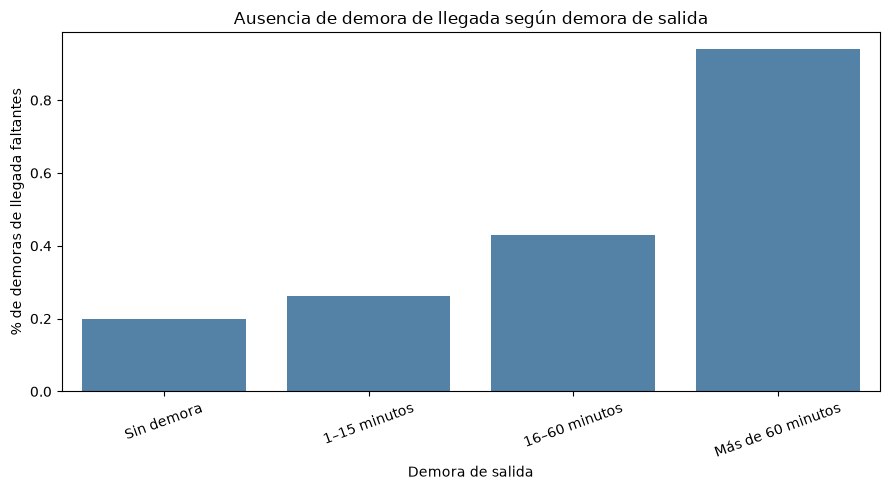

In [45]:
plot_data = missing_by_departure_delay.reset_index()

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=plot_data,
    x="departure_delay_group",
    y="porcentaje_nulos",
    color="steelblue"
)

plt.xlabel("Demora de salida")
plt.ylabel("% de demoras de llegada faltantes")
plt.title(
    "Ausencia de demora de llegada según demora de salida"
)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Observamos que la tasa de valores faltantes en **Arrival Delay in Minutes** aumenta progresivamente con **Departure Delay in Minutes**.

Este patrón observado sugiere que la ausencia no es completamente aleatoria y es compatible con una causa de tipo **MAR** relacionado con la demora de salida.

### Tratamiento de faltantes
Ya identificamos que la ausencia en `Arrival Delay in Minutes` está asociada a `Departure Delay in Minutes` (mecanismo MAR). En vez de eliminar esas filas, imputamos cada valor faltante con la mediana de `Arrival Delay in Minutes` correspondiente a su grupo de demora de salida.

In [46]:
departure_bins = [-1, 0, 15, 60, np.inf]

departure_labels = [
    "Sin demora",
    "1–15 minutos",
    "16–60 minutos",
    "Más de 60 minutos"
]

df_train["departure_delay_group"] = pd.cut(
    df_train["Departure Delay in Minutes"],
    bins=departure_bins,
    labels=departure_labels
)

arrival_medians_by_group = (
    df_train
    .groupby(
        "departure_delay_group",
        observed=True
    )["Arrival Delay in Minutes"]
    .median()
)

In [47]:
conditional_medians = (
    df_train["departure_delay_group"]
    .astype("object")
    .map(arrival_medians_by_group)
)

df_train["Arrival Delay in Minutes"] = (
    df_train["Arrival Delay in Minutes"]
    .fillna(conditional_medians)
    .astype("float64")
)

df_train.drop(
    columns="departure_delay_group",
    inplace=True
)

In [48]:
df_train.isna().sum()

id                                   0
Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
dtype: int64

Aplicamos el mismo criterio (con las medianas calculadas sobre train) al conjunto de test, para no filtrar información de test hacia el entrenamiento.

In [49]:
df_test["departure_delay_group"] = pd.cut(
    df_test["Departure Delay in Minutes"],
    bins=departure_bins,
    labels=departure_labels
)

test_conditional_medians = (
    df_test["departure_delay_group"]
    .astype("object")
    .map(arrival_medians_by_group)
)

df_test["Arrival Delay in Minutes"] = (
    df_test["Arrival Delay in Minutes"]
    .fillna(test_conditional_medians)
    .astype("float64")
)

df_test.drop(
    columns="departure_delay_group",
    inplace=True
)

Antes de codificar las variables, guardamos las columnas que necesita el `BaselineClassifier` en su forma original: al ser un modelo basado en reglas simples definidas sobre los valores crudos (`Class == "Business"`, `Type of Travel == "Business travel"`, etc.), no debe recibir las columnas ya transformadas por One-Hot Encoding.

In [50]:
baseline_columns = [
    "Baggage handling",
    "Seat comfort",
    "Flight Distance",
    "Type of Travel",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes",
    "Class",
]

X_baseline_train = df_train[baseline_columns].copy()

### Codificación
Aplicamos codificación a las variables categóricas nominales utilizando **One-Hot Encoding**

In [51]:
nominal_columns = [
    "Gender",
    "Customer Type",
    "Type of Travel",
    "Class"
]

ohe = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore",
    dtype=np.float64
)

train_encoded_array = ohe.fit_transform(df_train[nominal_columns])

test_encoded_array = ohe.transform(df_test[nominal_columns])

encoded_columns = ohe.get_feature_names_out(nominal_columns)

train_encoded_df = pd.DataFrame(
    data=np.asarray(
        train_encoded_array,
        dtype=np.float64
    ),
    columns=encoded_columns.tolist(),
    index=df_train.index.copy()
)

test_encoded_df = pd.DataFrame(
    data=np.asarray(
        test_encoded_array,
        dtype=np.float64
    ),
    columns=encoded_columns.tolist(),
    index=df_test.index.copy()
)

df_train = (
    df_train
    .drop(columns=nominal_columns)
    .join(train_encoded_df)
)

df_test = (
    df_test
    .drop(columns=nominal_columns)
    .join(test_encoded_df)
)

Aplicamos **Label Encoding** para codificar la variable target (Satisfaction)

In [52]:
label_encoder = LabelEncoder()

train_target_encoded = label_encoder.fit_transform(
    df_train["satisfaction"]
)

test_target_encoded = label_encoder.transform(
    df_test["satisfaction"]
)

df_train["satisfaction"] = pd.Series(
    data=np.asarray(
        train_target_encoded,
        dtype=np.int64
    ),
    index=df_train.index,
    dtype="int64"
)

df_test["satisfaction"] = pd.Series(
    data=np.asarray(
        test_target_encoded,
        dtype=np.int64
    ),
    index=df_test.index,
    dtype="int64"
)

In [53]:
df_train.head()

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,...,satisfaction,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus
0,70172,13,460,3,4,3,1,5,3,5,...,0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,5047,25,235,3,2,3,3,1,3,1,...,0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
2,110028,26,1142,2,2,2,2,5,5,5,...,1,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
3,24026,25,562,2,5,5,5,2,2,2,...,0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
4,119299,61,214,3,3,3,3,4,5,5,...,1,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


### Selección de features

In [54]:
TARGET = "satisfaction"

num_features = [
    "Age",
    "Flight Distance",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]

cat_ord_features = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Inflight service",
    "Cleanliness"
]

cat_nom_features = (
    ohe
    .get_feature_names_out(
        nominal_columns
    )
    .tolist()
)

cat_features = (
    cat_nom_features
    + cat_ord_features
)

all_features = (
    num_features
    + cat_features
)

In [55]:
X_train_num = (
    df_train[num_features]
    .astype(float)
)

X_train_cat = (
    df_train[cat_features]
    .astype(float)
)

y_train = (
    df_train[TARGET]
    .astype(int)
)

In [56]:
selector_anova = SelectKBest(score_func=f_classif, k="all")
selector_anova.fit(X_train_num, y_train)

if selector_anova.scores_ is None:
    raise RuntimeError(
        "SelectKBest no generó los scores de ANOVA"
    )

if selector_anova.pvalues_ is None:
    raise RuntimeError(
        "SelectKBest no generó los p-values de ANOVA"
    )

anova_scores_array = np.asarray(
    selector_anova.scores_,
    dtype=np.float64
)

anova_pvalues_array = np.asarray(
    selector_anova.pvalues_,
    dtype=np.float64
)

anova_scores = pd.Series(
    {
        feature: float(score)
        for feature, score in zip(
            num_features,
            anova_scores_array
        )
    },
    name="ANOVA_F"
)

anova_pvalues = pd.Series(
    {
        feature: float(p_value)
        for feature, p_value in zip(
            num_features,
            anova_pvalues_array
        )
    },
    name="ANOVA_p_value"
)

In [57]:
anova_results = (
    pd.DataFrame({
        "score": anova_scores,
        "p_value": anova_pvalues
    })
    .sort_values(
        "score",
        ascending=False
    )
)

display(
    anova_results.style.format({
        "score": "{:.2f}",
        "p_value": "{:.6f}"
    })
)

,score,p_value
Flight Distance,10184.42,0.000000
Age,1992.39,0.000000
Arrival Delay in Minutes,344.44,0.000000
Departure Delay in Minutes,265.59,0.000000


In [58]:
selector_chi2 = SelectKBest(score_func=chi2, k="all")
selector_chi2.fit(X_train_cat, y_train)

if selector_chi2.scores_ is None:
    raise RuntimeError(
        "SelectKBest no generó los scores de Chi²"
    )

if selector_chi2.pvalues_ is None:
    raise RuntimeError(
        "SelectKBest no generó los p-values de Chi²"
    )

chi2_scores_array = np.asarray(
    selector_chi2.scores_,
    dtype=np.float64
)

chi2_pvalues_array = np.asarray(
    selector_chi2.pvalues_,
    dtype=np.float64
)

chi2_scores = pd.Series(
    {
        feature: float(score)
        for feature, score in zip(
            cat_features,
            chi2_scores_array
        )
    },
    name="chi2"
)

chi2_pvalues = pd.Series(
    {
        feature: float(p_value)
        for feature, p_value in zip(
            cat_features,
            chi2_pvalues_array
        )
    },
    name="chi2_p_value"
)

In [59]:
chi2_results = (
    pd.DataFrame({
        "score": chi2_scores,
        "p_value": chi2_pvalues
    })
    .sort_values(
        "score",
        ascending=False
    )
)

display(
    chi2_results.style.format({
        "score": "{:.2f}",
        "p_value": "{:.6f}"
    })
)

,score,p_value
Online boarding,14761.96,0.000000
Type of Travel_Personal Travel,14445.75,0.000000
Class_Business,13769.29,0.000000
Class_Eco,11632.29,0.000000
Inflight entertainment,8711.18,0.000000
Type of Travel_Business travel,6501.44,0.000000
Seat comfort,6419.26,0.000000
Inflight wifi service,5422.33,0.000000
On-board service,5299.34,0.000000
Leg room service,5261.98,0.000000


In [60]:
mi_num = mutual_info_classif(X_train_num, y_train, discrete_features=False, random_state=42)
mi_num_series = pd.Series(mi_num, index=num_features, name="MI")

mi_cat = mutual_info_classif(X_train_cat, y_train, discrete_features=True, random_state=42)
mi_cat_series = pd.Series(mi_cat, index=cat_features, name="MI")

mi_all = pd.concat([mi_num_series, mi_cat_series])

mi_results = (
    mi_all
    .sort_values(
        ascending=False
    )
    .to_frame()
)

mi_results

,MI
Online boarding,0.210858
Inflight wifi service,0.161702
Class_Business,0.132830
Type of Travel_Business travel,0.113635
Type of Travel_Personal Travel,0.113635
Class_Eco,0.107171
Inflight entertainment,0.093717
Seat comfort,0.078879
Leg room service,0.060730
Flight Distance,0.060487


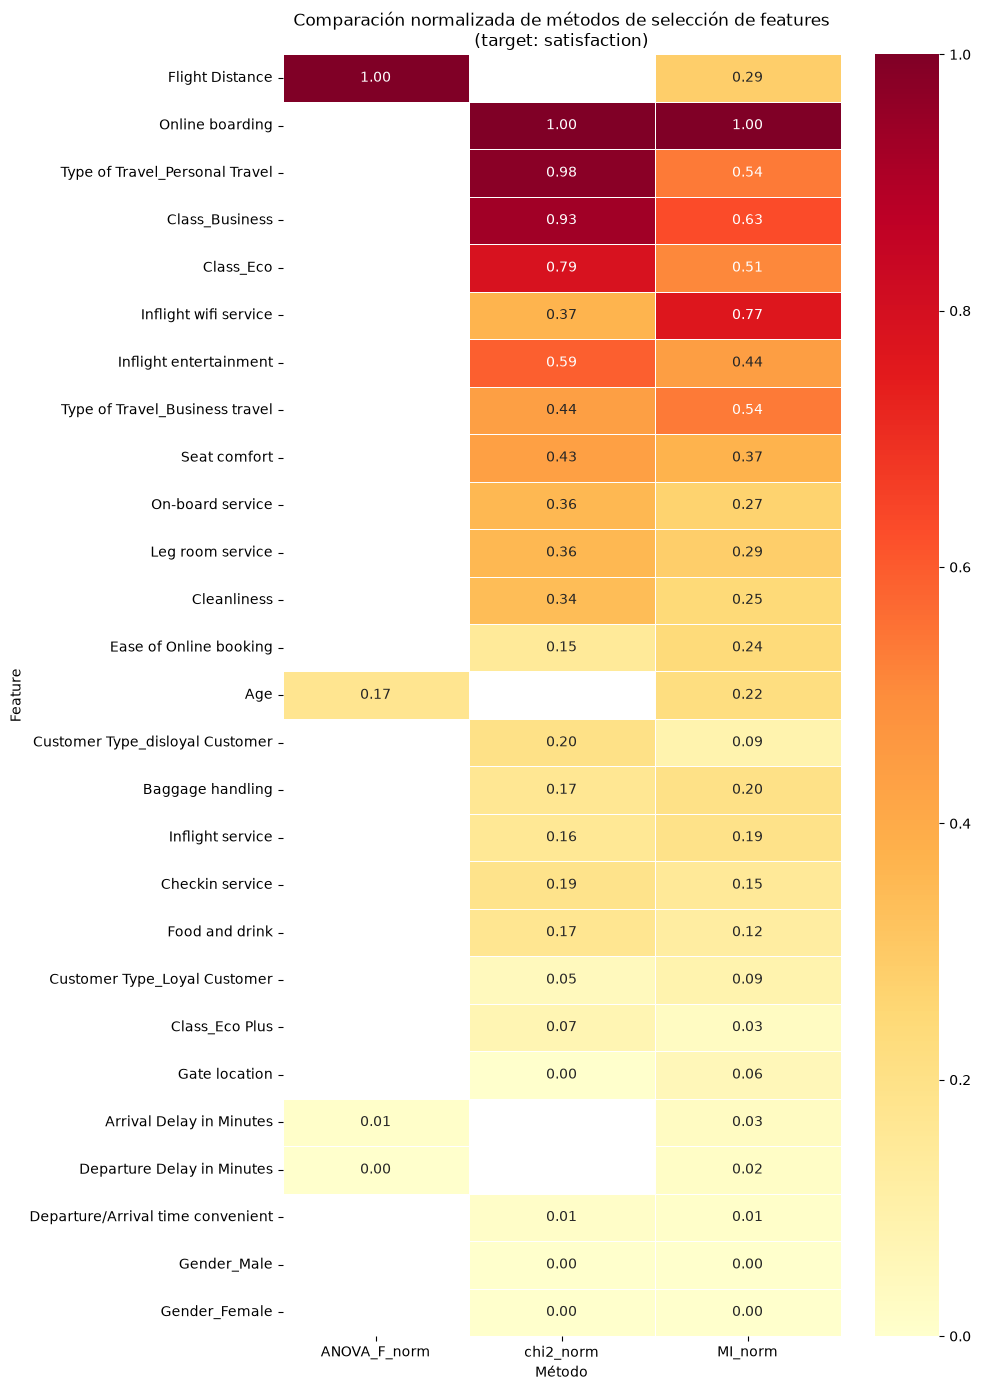

In [61]:
comparison_df = pd.DataFrame(index=all_features)

comparison_df["ANOVA_F_norm"] = pd.Series(
    MinMaxScaler()
    .fit_transform(
        anova_scores
        .to_numpy()
        .reshape(-1, 1)
    )
    .flatten(),
    index=num_features
)

comparison_df["chi2_norm"] = pd.Series(
    MinMaxScaler()
    .fit_transform(
        chi2_scores
        .to_numpy()
        .reshape(-1, 1)
    )
    .flatten(),
    index=cat_features
)

comparison_df["MI_norm"] = pd.Series(
    MinMaxScaler()
    .fit_transform(
        mi_all
        .to_numpy()
        .reshape(-1, 1)
    )
    .flatten(),
    index=all_features
)

comparison_df["max_score"] = (
    comparison_df[
        [
            "ANOVA_F_norm",
            "chi2_norm",
            "MI_norm"
        ]
    ]
    .max(axis=1)
)

comparison_df = (
    comparison_df
    .sort_values(
        "max_score",
        ascending=False
    )
    .drop(columns="max_score")
)

plt.figure(figsize=(10, 14))

sns.heatmap(
    comparison_df.astype(float),
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    linewidths=0.5
)

plt.title(
    "Comparación normalizada de métodos "
    "de selección de features\n"
    "(target: satisfaction)"
)

plt.xlabel("Método")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [62]:
selected_features = [
    # Numéricas
    "Age",
    "Flight Distance",
    "Arrival Delay in Minutes",

    # Variables nominales codificadas
    "Type of Travel_Personal Travel",
    "Class_Business",
    "Class_Eco",
    "Customer Type_disloyal Customer",

    # Servicios (ordinales)
    "Online boarding",
    "Inflight wifi service",
    "Inflight entertainment",
    "Seat comfort",
    "On-board service",
    "Leg room service",
    "Cleanliness",
    "Ease of Online booking",
    "Baggage handling",
    "Inflight service",
    "Checkin service",
    "Food and drink"
]

In [63]:
X_train = df_train[selected_features].copy()
y_train = df_train["satisfaction"].copy()

X_test = df_test[selected_features].copy()
y_test = df_test["satisfaction"].copy()

### Estandarización

In [64]:
numeric_selected_features = [
    "Age",
    "Flight Distance",
    "Arrival Delay in Minutes"
]

scaler = StandardScaler()

train_standardized_array = scaler.fit_transform(X_train[numeric_selected_features])

test_standardized_array = scaler.transform(X_test[numeric_selected_features])

X_train_standardized = pd.DataFrame(
    data=np.asarray(
        train_standardized_array,
        dtype=np.float64
    ),
    columns=numeric_selected_features,
    index=X_train.index
)

X_test_standardized = pd.DataFrame(
    data=np.asarray(
        test_standardized_array,
        dtype=np.float64
    ),
    columns=numeric_selected_features,
    index=X_test.index
)

X_train = pd.concat(
    [X_train.drop(columns=numeric_selected_features), X_train_standardized],
    axis=1
)

X_test = pd.concat(
    [X_test.drop(columns=numeric_selected_features), X_test_standardized],
    axis=1
)

In [65]:
print(
    X_train[numeric_selected_features]
    .describe()
    .loc[["mean", "std", "min", "max"]]
    .round(6)
)

           Age  Flight Distance  Arrival Delay in Minutes
mean -0.000000         0.000000                 -0.000000
std   1.000005         1.000005                  1.000005
min  -2.142239        -1.161768                 -0.393128
max   3.018235         3.804423                 40.531052


## Planteamiento del problema
El problema que planteamos es de tipo clasificación binaria (`satisfied`, `neutral or dissatisfied`). Queremos predecir si un cliente calificará el vuelo como satisfactorio o no.

Por prolijidad, renombramos `neutral or dissatisfied` a `not_satisfied` 

In [66]:
df_analysis["satisfaction"] = df_analysis["satisfaction"].cat.rename_categories({"neutral or dissatisfied": "not satisfied"})
df_analysis["satisfaction"]

0         not satisfied
1         not satisfied
2             satisfied
3         not satisfied
4             satisfied
              ...      
103899    not satisfied
103900        satisfied
103901    not satisfied
103902    not satisfied
103903    not satisfied
Name: satisfaction, Length: 103904, dtype: category
Categories (2, str): ['not satisfied', 'satisfied']

In [67]:
summary_by_satisfaction = (
    df_analysis
    .groupby("satisfaction")[numeric_columns]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

summary_by_satisfaction

Age                      Flight Distance                   \
               count   mean median    std           count     mean  median   
satisfaction                                                                 
not satisfied  58879  37.57   36.0  16.46           58879   928.92   671.0   
satisfied      45025  41.75   43.0  12.77           45025  1530.14  1250.0   

                       Departure Delay in Minutes                       \
                   std                      count   mean median    std   
satisfaction                                                             
not satisfied   790.45                      58879  16.50    0.0  40.19   
satisfied      1128.13                      45025  12.61    0.0  35.38   

              Arrival Delay in Minutes                       
                                 count   mean median    std  
satisfaction                                                 
not satisfied                    58697  17.13    0.0  40.56  
satisfied                        44897  12.63    0.0  35.96

Guardamos el dataframe procesado

In [68]:
df_analysis.to_csv("./datasets/df_analysis.csv", index=False)

## Definición del Baseline

Vamos a crear un baseline para predecir la salida a partir de un promedio ponderado. Las categorías y sus pesos son arbitrarios y fueron definidos según nuestro criterio personal. Es decir, pensamos qué nos importaría a nosotros a la hora de hacer un vuelo y en qué medida.

Para esto seleccionamos seis variables que binarizamos según nuestro criterio:

Dimensión|Columna en el dataset|Peso|Observaciones
| --- | --- | --- | --- |
Clase en la que viajamos|`Class`|30%| 1 si la clase era Business y 0 si no
Manejo del equipaje|`Baggage handling`|20%| Si la puntuación era mayor a 3, lo tomamos como 1 
Si no tiene demoras|`Departure Delay in Minutes` y `Arrival Delay in Minutes`|20%| Consideramos que no tiene demora si ni en la salida ni en la llegada se excede más de 15 minutos
Comodidad de los asientos|`Seat comfort`|10%| Ídem a "Manejo del equipaje"
Si es un vuelo por trabajo|`Type of Travel`|10%| Tomamos 1 si era un vuelo de trabajo
Si el viaje es corto|`Flight Distance`|10%| Si es un vuelo de menos de 1000 millas, lo consideramos corto

Se guarda como `BaselineClassifier` para que sea polimórfico y fácilmente comparable

## Comparativa de modelos

El problema de clasificación que elegimos no tiene un fuerte desbalance de clases y es binario. Para el negocio, sospechamos que es más importante evitar los falsos positivos de clasificación satisfactoria. Entendemos que es preferible ser más exigente para considerar que un pasajero está satisfecho con su vuelo ya que la insatisfacción implica un accionable.
Para que sean fácilmente accesibles, vamos a guardar las métricas en el objeto `MetricsCollector`. 

También, cada clasificador podría necesitar una codificación específica. Vamos a preservar nuestro dataset analizado y vamos a aplicar la transformación necesaria en las columnas necesarias para cada modelo en su respectivo pipeline

In [69]:

collector = MetricsCollector()

target_var = "satisfaction"
pos_label  = "satisfied"

# Elimino la target de la lista nominal_categorical__columns para ajustar los pipelines
nominal_features = [c for c in nominal_categorical__columns if c != target_var]

######
#df_analysis no deberia tener nans despues del EDA
######
### Arreglar y luego eliminar esto
df_analysis = df_analysis.dropna()
### Arreglar y luego eliminar esto


X_train, y_train = df_analysis.drop(target_var, axis=1), df_analysis[target_var]


#Preprocesador para modelos lineales que no aceptan categóricas y que necesitan que las numéricas estén escaladas
#service_columns son ordinales y se escalan igual
preprocessor_linear = ColumnTransformer([
    ("numeric",     StandardScaler(), numeric_columns),
    ("service", StandardScaler(), service_columns),      
    ("nominal",     OneHotEncoder(handle_unknown="ignore"), nominal_features),
])

preprocessor_tree = ColumnTransformer([
    ("numeric", "passthrough", numeric_columns),
    ("nominal", OneHotEncoder(handle_unknown="ignore"), nominal_features),
])

### Pipelines por modelo

In [70]:
models = {
    "Baseline": BaselineClassifier(),   

    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor_linear),
        ("model",  LogisticRegression(max_iter=1000, 
                                      random_state=42)),
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("model",  RandomForestClassifier(random_state=42)),
    ]),

    "SVM": Pipeline([
        ("preprocessor", preprocessor_linear),
        ("model",  SVC(random_state=42)),
    ]),
}


## Comparativa

Como métrica principal vamos a usar fbeta_score que es un f1_score ponderado a partir del factor $\beta^2$. Con beta de 0.5 se le da más peso al valor de la precision por sobre el recall. Como el `pos_label` se seteó como `satisfied`, terminamos castigando más los falsos positivos de satisfechos que de no satisfechos 

$$F_\beta = (1 + \beta^2) \cdot \frac{\text{precision} \cdot \text{recall}}{\beta^2 \cdot \text{precision} + \text{recall}}$$

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    y_pred = cross_val_predict(model, X_train, y_train, cv=cv)
    collector.add(name, eval_metrics(y_train, y_pred, pos_label))

collector.to_dataframe().sort_values('fbeta_0.5', ascending=False).round(4)

## Evaluación final en test

## Conclusiones
_TODO: interpretar los resultados (por qué ganó el modelo elegido, qué features pesaron más, límites del análisis, próximos pasos como tuning de hiperparámetros)._